In [2]:
#09/02/2025

import os
import scanpy as sc
import anndata
import numpy as np
import scvi
import logging




scvi.settings.dl_num_workers = 14

# Configurar el logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

def read_and_combine_h5ad(directory):
    logging.info(f"Leyendo archivos h5ad desde el directorio: {directory}")
    adata= sc.read_h5ad(directory)
    logging.info(f"adata shape: {adata.shape}")
    # Antes de configurar scVI, agregar:
    adata.raw = adata  # Mantener datos completos seguros

    # Verificar y guardar conteos crudos
    if 'counts' not in adata.layers:
        logging.info("Guardando conteos crudos en layer 'counts'")
        adata.layers['counts'] = adata.X.copy()

    if 'unscaled' not in adata.layers:
        raise ValueError("No se encontró layer 'unscaled'. Ejecutar normalización primero.")
    
        
    # Verificar que son conteos enteros
    if not np.issubdtype(adata.layers['counts'].dtype, np.integer):
        logging.warning("Los datos en layer 'counts' no son enteros")
    else:
        logging.info("Verificación exitosa: conteos son enteros")
    
    
    return adata


# Leer y combinar archivos h5ad
directory = '/app/project/restore_data/pipeline_articulo/3.5normalized&scaled_by_group/processed_filtered_filtered_NK cells_data.h5ad'
adata = read_and_combine_h5ad(directory)


2025-02-09 09:32:22,130 - INFO - Leyendo archivos h5ad desde el directorio: /app/project/restore_data/pipeline_articulo/3.5normalized&scaled_by_group/processed_filtered_filtered_NK cells_data.h5ad
2025-02-09 09:32:42,053 - INFO - adata shape: (339144, 7000)
2025-02-09 09:32:42,056 - WARNING - Los datos en layer 'counts' no son enteros


In [4]:
import scipy
# 1. Para revisar adata.X
print("Revisando adata.X:")
# Si es una matriz dispersa
if scipy.sparse.issparse(adata.X):
    print("adata.X es una matriz dispersa")
    print("Primeros 5 elementos de las primeras 3 células:")
    print(adata.X[:3,:5].toarray())
else:
    print("adata.X es una matriz densa")
    print("Primeros 5 elementos de las primeras 3 células:")
    print(adata.X[:3,:5])

# 2. Para revisar adata.layers['counts']  
print("\nRevisando adata.layers['counts']:")
if scipy.sparse.issparse(adata.layers['counts']):
    print("Layer counts es una matriz dispersa")
    print("Primeros 5 elementos de las primeras 3 células:")
    print(adata.layers['counts'][:3,:5].toarray())
else:
    print("Layer counts es una matriz densa")
    print("Primeros 5 elementos de las primeras 3 células:") 
    print(adata.layers['counts'][:3,:5])

# 3. Información adicional útil
print("\nInformación general:")
print(f"Tipo de datos en adata.X: {adata.X.dtype}")
print(f"Tipo de datos en counts: {adata.layers['counts'].dtype}")

# 4. Estadísticas básicas
print("\nEstadísticas básicas:")
print("adata.X - rango de valores:")
print(f"Min: {adata.X.min()}, Max: {adata.X.max()}")
print("counts - rango de valores:")
print(f"Min: {adata.layers['counts'].min()}, Max: {adata.layers['counts'].max()}")

Revisando adata.X:
adata.X es una matriz densa
Primeros 5 elementos de las primeras 3 células:
[[-0.31795939 -1.16818523 -0.29676717 -0.29633143 -0.24614383]
 [-0.31770909 -1.16660038 -0.29617707 -0.29597161 -0.24589245]
 [-0.32661804 -0.85629959 -0.34298771 -0.26227583 -0.24227116]]

Revisando adata.layers['counts']:
Layer counts es una matriz dispersa
Primeros 5 elementos de las primeras 3 células:
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]

Información general:
Tipo de datos en adata.X: float64
Tipo de datos en counts: float32

Estadísticas básicas:
adata.X - rango de valores:
Min: -5.0, Max: 5.0
counts - rango de valores:
Min: 0.0, Max: 49548.0


In [5]:
# Verifiquemos más a fondo los datos
print("Distribución de valores en counts:")
if scipy.sparse.issparse(adata.layers['counts']):
    counts_array = adata.layers['counts'].toarray()
else:
    counts_array = adata.layers['counts']

print("Número de ceros:", np.sum(counts_array == 0))
print("Valores únicos (primeros 10):", np.unique(counts_array)[:10])
print("¿Hay valores decimales?:", 
      np.any(np.mod(counts_array, 1) != 0))

Distribución de valores en counts:
Número de ceros: 2142762965
Valores únicos (primeros 10): [0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
¿Hay valores decimales?: False


In [7]:
# Verificación para matrices dispersas
if scipy.sparse.issparse(adata.layers['counts']):
    # Convertir a array denso para verificación
    counts_array = adata.layers['counts'].toarray()
else:
    counts_array = adata.layers['counts']

# Ahora podemos verificar si son efectivamente conteos
if np.all(np.mod(counts_array, 1) < 1e-10):
    print("Los valores parecen ser conteos (considerando tolerancia numérica)")
    if scipy.sparse.issparse(adata.layers['counts']):
        adata.layers['counts'] = scipy.sparse.csr_matrix(counts_array.astype(np.int32))
    else:
        adata.layers['counts'] = counts_array.astype(np.int32)
    print("Conversión a enteros exitosa")
else:
    print("Se detectaron valores no enteros en los conteos")
    # Mostrar algunos ejemplos de valores no enteros
    non_integer_mask = np.mod(counts_array, 1) >= 1e-10
    print("Ejemplos de valores no enteros:")
    print(counts_array[non_integer_mask][:10])

Los valores parecen ser conteos (considerando tolerancia numérica)
Conversión a enteros exitosa


In [8]:
import logging
import scanpy as sc
import scvi
from lightning.pytorch.callbacks import LearningRateMonitor, EarlyStopping

# Configurar anndata para scVI
logging.info("Configurando anndata para scVI")
scvi.model.SCVI.setup_anndata(
    adata,
    layer="counts",
    batch_key='short_title',
    categorical_covariate_keys=['assay', 'self_reported_ethnicity', 'sex']
)

# Entrenar modelo scVI con los parámetros de normalización
logging.info("Entrenando modelo scVI")
scvi_model = scvi.model.SCVI(
    adata, 
    n_latent=30,
    n_layers=2,
    n_hidden=128,
    gene_likelihood="nb",
    dropout_rate=0.1,
    use_layer_norm='both',
    use_batch_norm='both'
)

# Configurar callbacks
callbacks = [
    EarlyStopping(
        monitor='validation_loss',
        min_delta=0.001,
        patience=30,
        mode='min'
    ),
    LearningRateMonitor(logging_interval='epoch')
]

# Plan de entrenamiento con reducción de learning rate y KL warmup
plan_kwargs = {
    'lr': 1e-3,
    'reduce_lr_on_plateau': True,
    'lr_factor': 0.6,
    'lr_patience': 10,
    'lr_threshold': 0.001,
    'lr_min': 1e-6,
    'n_steps_kl_warmup': 30  # Movido aquí
}

# Entrenamiento del modelo
scvi_model.train(
    max_epochs=600,
    early_stopping=True,
    check_val_every_n_epoch=1,
    train_size=0.9,
    callbacks=callbacks,
    plan_kwargs=plan_kwargs
)

# Guardar el modelo
print('# Guardar el modelo scVI')
scvi_model_save_path = '/app/project/restore_data/pipeline_articulo/4.models/scvi_model'
scvi_model.save(scvi_model_save_path, overwrite=True)

# Obtener representaciones latentes
SCVI_LATENT_KEY = "X_scVI"
adata.obsm[SCVI_LATENT_KEY] = scvi_model.get_latent_representation()

# Calcular vecinos y clustering
logging.info("Calculating neighbors")
sc.pp.neighbors(adata, use_rep=SCVI_LATENT_KEY)

logging.info("Running Leiden algorithm")
sc.tl.leiden(adata, flavor="igraph", n_iterations=2, directed=False)


2025-02-09 20:52:51,812 - INFO - Configurando anndata para scVI
2025-02-09 20:52:52,211 - INFO - Unable to initialize backend 'cuda': 
2025-02-09 20:52:52,212 - INFO - Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
2025-02-09 20:52:52,682 - INFO - Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
2025-02-09 20:52:52,684 - WARNING - An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
2025-02-09 20:52:53,265 - INFO - Entrenando modelo scVI
Trainer will use only 1 of 3 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=3)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 

Epoch 1/600:   0%|          | 0/600 [00:00<?, ?it/s]

/root/.pyenv/versions/3.9.7/lib/python3.9/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Epoch 2/600:   0%|          | 1/600 [01:08<11:22:18, 68.34s/it, v_num=1, train_loss_step=1.85e+3, train_loss_epoch=2.07e+3]

/root/.pyenv/versions/3.9.7/lib/python3.9/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/root/.pyenv/versions/3.9.7/lib/python3.9/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/root/.pyenv/versions/3.9.7/lib/python3.9/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/root/.pyenv/versions/3.9.7/lib/python3.9/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.

...

Epoch 46/600:   8%|▊         | 46/600 [55:42<11:11:01, 72.67s/it, v_num=1, train_loss_step=1.84e+3, train_loss_epoch=1.96e+3]

/root/.pyenv/versions/3.9.7/lib/python3.9/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


/root/.pyenv/versions/3.9.7/lib/python3.9/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


# Guardar el modelo scVI


/root/.pyenv/versions/3.9.7/lib/python3.9/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/root/.pyenv/versions/3.9.7/lib/python3.9/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
2025-02-09 21:49:07,025 - INFO - Calculating neighbors
2025-02-09 21:51:05,252 - INFO - Running Leiden algorithm


2025-02-09 22:55:27,983 - INFO - Calculating UMAP


<Figure size 1200x500 with 0 Axes>

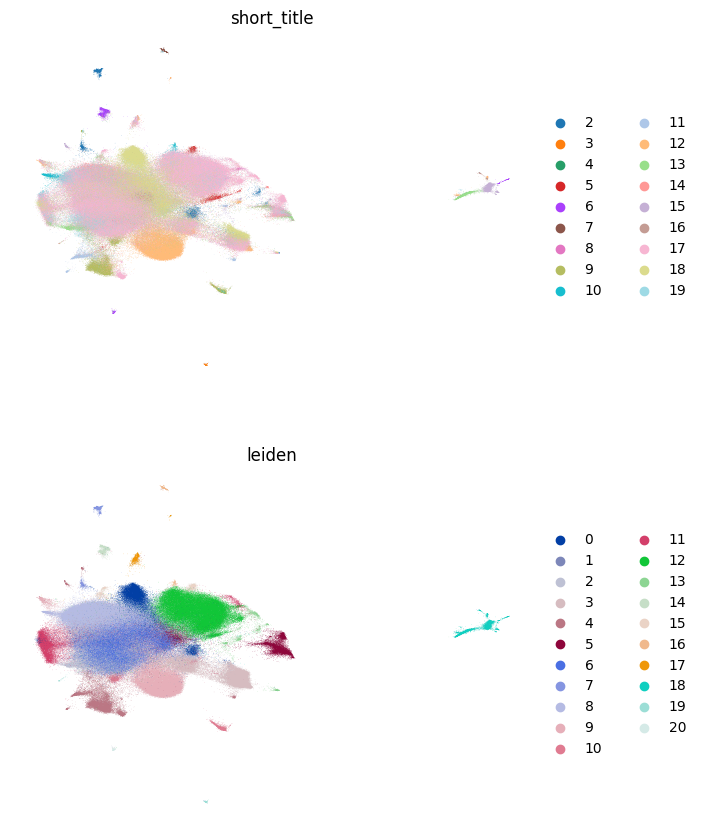

<Figure size 800x600 with 0 Axes>

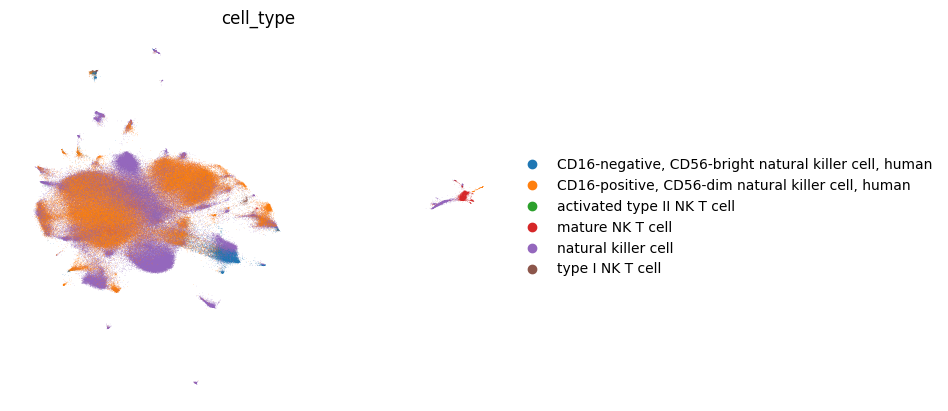

2025-02-09 23:03:25,976 - INFO - Guardando resultados en: /app/project/restore_data/pipeline_articulo/4.models/scvi_model/scvi_integrated.h5ad
2025-02-09 23:12:02,987 - INFO - Finalización del script


In [9]:
import matplotlib.pyplot as plt


# Calcular UMAP
logging.info("Calculating UMAP")
sc.tl.umap(adata, min_dist=0.1)

# Definir rutas para guardar las visualizaciones
sc.settings.figdir = '/app/project/restore_data/pipeline_articulo/4.models/scvi_model'

# Guardar UMAP por muestra y clustering
plt.figure(figsize=(12, 5))
sc.pl.umap(
    adata,
    color=["short_title", "leiden"],
    frameon=False,
    ncols=1,
    save='_sample_and_clustering.png'
)
plt.close()

# Guardar UMAP por tipo celular
plt.figure(figsize=(8, 6))
sc.pl.umap(
    adata,
    color=["cell_type"],
    frameon=False,
    save='_cell_type.png'
)
plt.close()

# Guardar el objeto anndata con los resultados
output_path = '/app/project/restore_data/pipeline_articulo/4.models/scvi_model/scvi_integrated.h5ad'
logging.info(f"Guardando resultados en: {output_path}")
adata.write(output_path)

logging.info("Finalización del script")

In [4]:
adata.obs['short_title']

barcodekey
444-0        2
445-0        2
446-0        2
447-0        2
448-0        2
            ..
385370-0    19
385371-0    19
385372-0    19
385373-0    19
385374-0    19
Name: short_title, Length: 339144, dtype: category
Categories (18, object): ['2', '3', '4', '5', ..., '16', '17', '18', '19']